## Medidas Estatísticas

### Objetivo da atividade

Nosso objetivo nessa atividade é trabalhar o uso de medidas estatísticas em conjuntos de dados
reais, assim como trabalhar com suas interpretações. Para isso iremos trabalhar com dois conjuntos
de dados reais, oriundos do Instituto Chico Mendes de Conservação da Biodiversidade (ICMBio),
disponíveis no link. Para cada conjunto de dados, serão pedidas algumas análises, das quais se espera
que o aluno seja capaz de apresentar código e discussão (explicar a escolha de cada função/comando
usado, bem como interpretação dos resultados encontrados) em um Jupyter Notebook.

### Tarefa 1: Queimadas em unidades de conservação ambiental no Brasil

1) Considere a variável referente à área atingida por incêndios em hectares. Construa uma tabela
de distribuição de frequências contendo frequências absoluta, relativa e acumulada. Em seguida,
elabore um histograma para representar a distribuição dos dados. A partir dos resultados obtidos,
discuta se os incêndios tendem a se concentrar em áreas pequenas, médias ou grandes, e avalie
se a distribuição aparenta ser simétrica ou assimétrica.

    fi  fr  Fi    Fr
0    3  4%   3    4%
1    1  1%   4    5%
2    1  1%   5    6%
3    1  1%   6    8%
4    1  1%   7    9%
..  ..  ..  ..   ...
72   1  1%  75   95%
73   1  1%  76   96%
74   1  1%  77   97%
75   1  1%  78   99%
76   1  1%  79  100%

[77 rows x 4 columns]


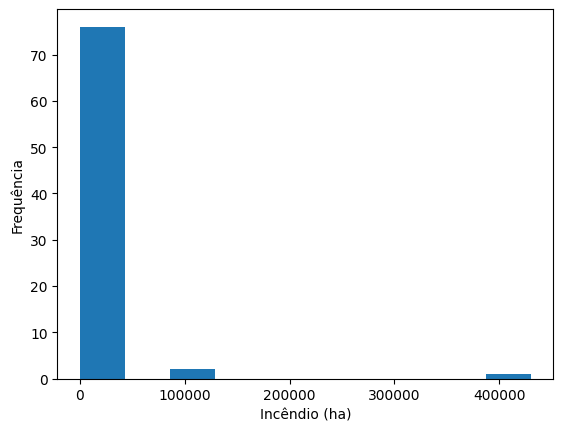

In [ ]:
# Importações
import matplotlib.pyplot as plt
import pandas as pd

# Carregamento dos dados
df_queimadas = pd.read_excel("queimadas_conservacao.xlsx")

# Gerando uma tabela de distribuição
# para a coluna de incêndios por ha
contagens = df_queimadas["Incêndio (ha)"].value_counts().sort_index()

# Cálculo das frequências
fi = contagens.values
fr = contagens.values / contagens.sum() * 100
Fi = contagens.cumsum().values
Fr = fr.cumsum()

tabela_freq = pd.DataFrame({
    "fi": fi,
    "fr": fr.round(0).astype(int).astype(str) + "%",
    "Fi": Fi,
    "Fr": Fr.round(0).astype(int).astype(str) + "%"
})

print(tabela_freq)

# Gerando um histograma a partir da tabela gerada
plt.hist(df_queimadas["Incêndio (ha)"])
plt.xlabel("Incêndio (ha)")
plt.ylabel("Frequência")

plt.show()

- A partir do histograma é possível dizer que as queimadas ocorrem majoritariamente em áreas pequenas e a distribuição é completamente assimétrica, se concentrando à esquerda do histograma.

2) Utilizando a variável correspondente ao total de área afetada por fogo, calcule as medidas de
tendência central média, mediana e moda. Compare os valores encontrados e discuta qual dessas
medidas representa melhor o comportamento dos dados. Analise também a possível influência de
valores extremos sobre os resultados.

In [ ]:
# Importação
from scipy import stats
import numpy as np

resultado_moda = stats.mode(df_queimadas["TOTAL INCÊNDIO  (ha) "])
moda = resultado_moda.mode
media = np.mean(df_queimadas["TOTAL INCÊNDIO  (ha) "])
mediana = np.median(df_queimadas["TOTAL INCÊNDIO  (ha) "])

print("-"*20)
print(f"Moda: {moda:.2f}\nMédia; {media:.2f}\nMediana: {mediana:.2f}")
print("-"*20)

--------------------
Moda: 0.00
Média; 10892.81
Mediana: 171.46
--------------------


- Após a análise dos dados gerados, a medida mais coerente em relação ao comportamento dos dados é a mediana. O problema com a moda é que a coluna possui muitos valores iguais a 0 (provavelmente erros de preenchimento de formulários) repetidos e isso faz com que o seu valor seja desintencionalmente manipulado, enquanto o problema com a média é que valores muito altos ou baixos em relação aos demais enviesam o resultado final.

3) Para a variável referente à área total de incêndios, calcule as seguintes medidas de dispersão:
variância, desvio padrão e intervalo interquartil. Com base nos resultados, interprete o nível de
variabilidade presente nos dados e discuta se o conjunto pode ser considerado homogêneo ou
heterogêneo.

In [ ]:
variancia = np.var(df_queimadas["TOTAL INCÊNDIO  (ha) "])
desvio = np.std(df_queimadas["TOTAL INCÊNDIO  (ha) "])
intervalo = np.quantile(df_queimadas["TOTAL INCÊNDIO  (ha) "], [0, 0.25, 0.5, 0.75, 1])

print("-"*25)
print(f"Variância: {variancia:.2f}\nDesvio; {desvio:.2f}\nIntervalo:")
labels = ["Mín", "Q1", "Mediana", "Q3", "Máx"]
for label, val in zip(labels, intervalo):
  print(f" {label}: {val:.2f}")
print("-"*25)

-------------------------
Variância: 2541413550.88
Desvio; 50412.43
Intervalo:
 Mín: 0.00
 Q1: 40.46
 Mediana: 171.46
 Q3: 1369.10
 Máx: 430265.85
-------------------------


- Os dados revelam que o desvio é quase 300x maior que a mediana, ou seja, há valores extremos (outliers) que estão modificando o resultado final. Além disso, 75% dos dados (Q3) estão abaixo de 1.369,10, isso significa que a maior concentração dos dados está em valores pequenos, como visto anteriormente.

- A distribuição dos dados é assimétrica à direita e altamente heterogêneo.

4) Compare estatisticamente as variáveis relacionadas às estratégias de manejo do fogo, como
Queima prescrita (ha), Queima controlada (ha), Gestão de ignição natural (ha) e Gestão de ignição
antrópica (ha). Calcule medidas de posição e dispersão para cada variável e construa gráficos
adequados para comparação. Discuta quais estratégias apresentam maior variabilidade e quais
possuem valores típicos mais elevados.

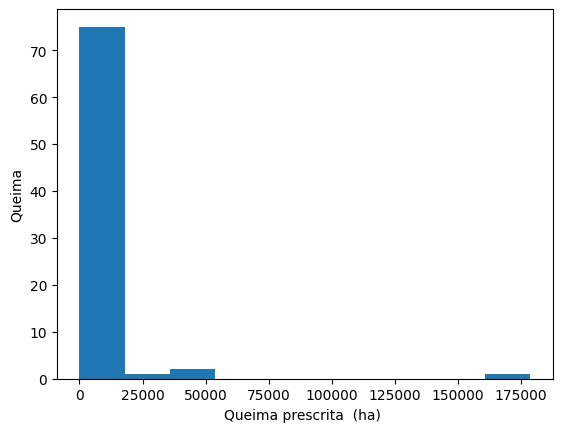

---------------------------------------------
Variável: Queima prescrita  (ha) 
  Média:    4526.00
  Mediana:  0.00
  Q1:       0.00
  Q3:       228.42
  Desvio:   21209.83
  CV:       468.62%
---------------------------------------------


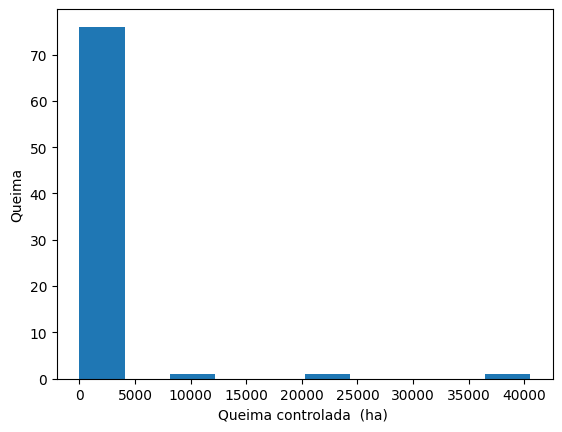

---------------------------------------------
Variável: Queima controlada  (ha) 
  Média:    1026.61
  Mediana:  0.00
  Q1:       0.00
  Q3:       0.00
  Desvio:   5251.24
  CV:       511.51%
---------------------------------------------


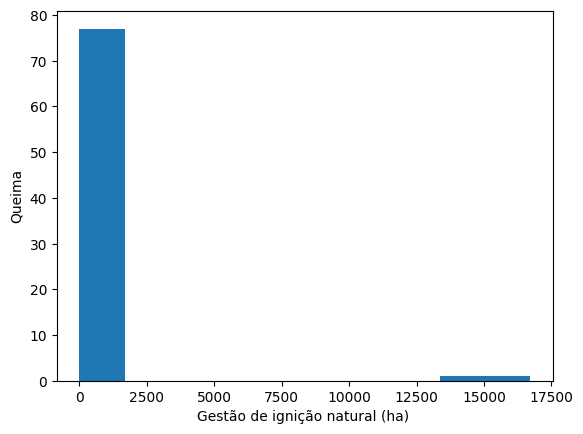

---------------------------------------------
Variável: Gestão de ignição natural (ha) 
  Média:    423.30
  Mediana:  0.00
  Q1:       0.00
  Q3:       0.00
  Desvio:   2411.00
  CV:       569.58%
---------------------------------------------


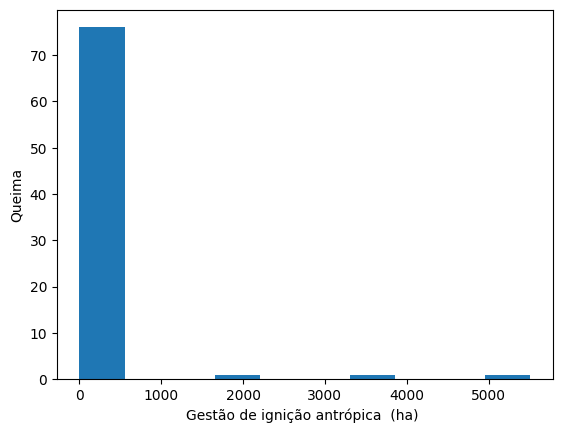

---------------------------------------------
Variável: Gestão de ignição antrópica  (ha) 
  Média:    139.52
  Mediana:  0.00
  Q1:       0.00
  Q3:       0.00
  Desvio:   754.44
  CV:       540.73%
---------------------------------------------


In [ ]:
def pos_dispersao(coluna, tipo):
    media = np.mean(coluna)
    mediana = np.median(coluna)
    q1 = np.percentile(coluna, 25)
    q3 = np.percentile(coluna, 75)
    desvio = np.std(coluna)
    cv = (desvio / media) * 100


    # Exibição de gráficos para cada variável
    if tipo == "hist":
      plt.hist(coluna)
    elif tipo == "boxplot":
      plt.boxplot(coluna)
    plt.xlabel(coluna.name)
    plt.ylabel("Queima")
    plt.show()

    print("-" * 45)
    print(f"Variável: {coluna.name}")
    print(f"  Média:    {media:.2f}")
    print(f"  Mediana:  {mediana:.2f}")
    print(f"  Q1:       {q1:.2f}")
    print(f"  Q3:       {q3:.2f}")
    print(f"  Desvio:   {desvio:.2f}")
    print(f"  CV:       {cv:.2f}%")
    print("-" * 45)

colunas = [
  df_queimadas["Queima prescrita  (ha) "],
  df_queimadas["Queima controlada  (ha) "],
  df_queimadas["Gestão de ignição natural (ha) "],
  df_queimadas["Gestão de ignição antrópica  (ha) "]
]

for col in colunas:
    pos_dispersao(col, "hist")

- As variáveis de queima prescrita e queima controlada são as que apresentam o maior desvio padrão, sendo as estratégias que possuem a maior variabilidade do conjunto

- A queima prescrita é a única com valor típico elevado, pelo menos 25% dos registros não nulos chegam a 228 ha ou mais

5) Construa boxplots para as variáveis Incêndio (ha), TOTAL MANEJO (ha) e % de AAF na UC. Identifique os quartis, o intervalo interquartil e possíveis valores discrepantes. Compare visualmente as distribuições e discuta qual variável apresenta maior dispersão e presença de outliers.

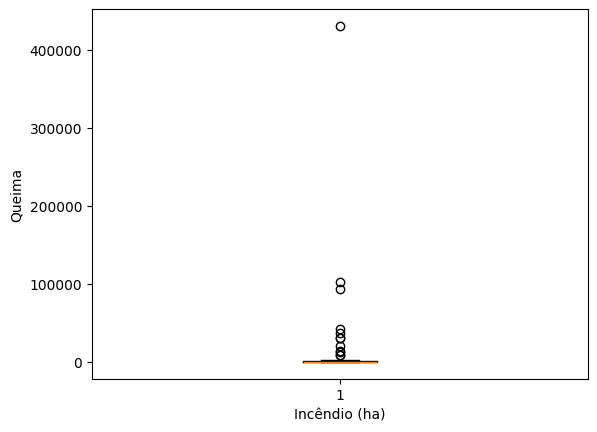

---------------------------------------------
Variável: Incêndio (ha)
  Média:    10892.81
  Mediana:  171.46
  Q1:       40.46
  Q3:       1369.10
  Desvio:   50412.43
  CV:       462.80%
---------------------------------------------


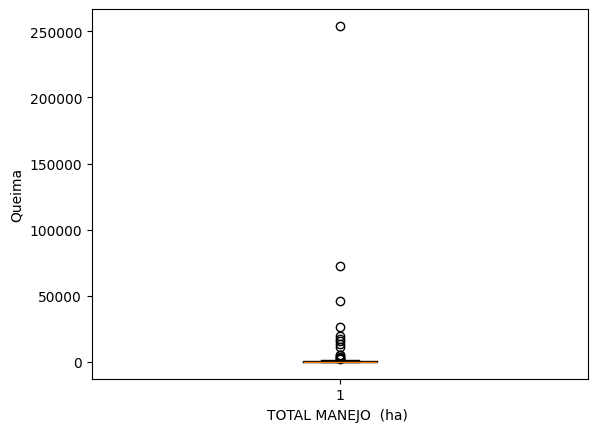

---------------------------------------------
Variável: TOTAL MANEJO  (ha) 
  Média:    6433.37
  Mediana:  0.00
  Q1:       0.00
  Q3:       748.34
  Desvio:   29929.91
  CV:       465.23%
---------------------------------------------


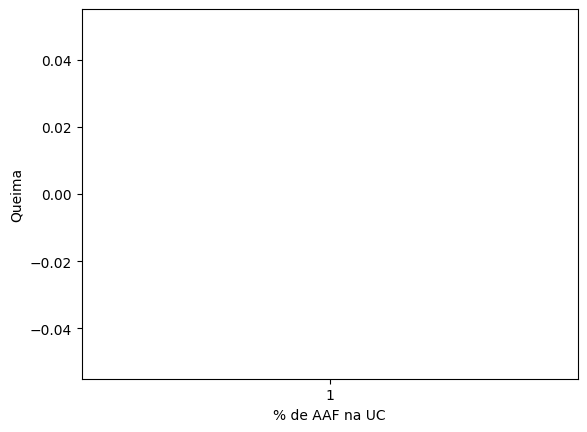

---------------------------------------------
Variável: % de AAF na UC
  Média:    3.97
  Mediana:  nan
  Q1:       nan
  Q3:       nan
  Desvio:   7.00
  CV:       176.38%
---------------------------------------------


In [ ]:
colunas = [
    df_queimadas["Incêndio (ha)"],
    df_queimadas["TOTAL MANEJO  (ha) "],
    df_queimadas["% de AAF na UC"],
]

for col in colunas:
  pos_dispersao(col, "boxplot")

- É possível notar que a variável % e AAF possui a maior dispersão dado a maior atual da caixa e a maior quantidade de outliers

6) A base de dados está organizada por anos. Escolha pelo menos três anos distintos e construa box-plots comparativos da variável TOTAL INCÊNDIO (ha). Analise as diferenças entre as distribuições observadas, comparando medianas, amplitudes e presença de valores extremos. Discuta quais
anos aparentam ter sido mais críticos em relação às áreas queimadas.

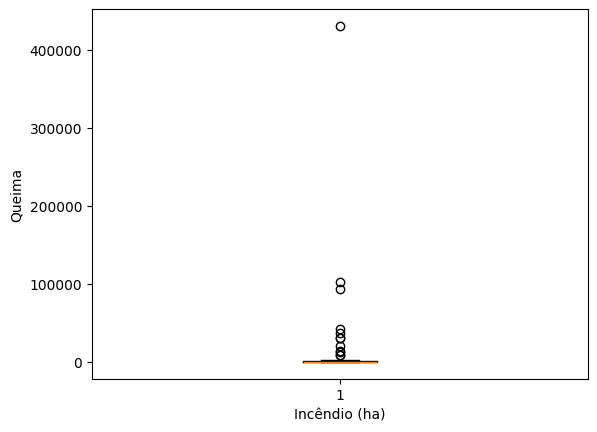

---------------------------------------------
Variável: Incêndio (ha)
  Média:    10892.81
  Mediana:  171.46
  Q1:       40.46
  Q3:       1369.10
  Desvio:   50412.43
  CV:       462.80%
---------------------------------------------


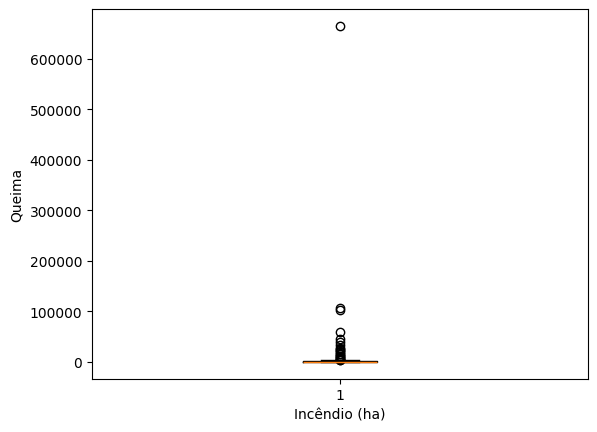

---------------------------------------------
Variável: Incêndio (ha)
  Média:    9431.36
  Mediana:  293.63
  Q1:       56.13
  Q3:       1483.81
  Desvio:   57372.81
  CV:       608.32%
---------------------------------------------


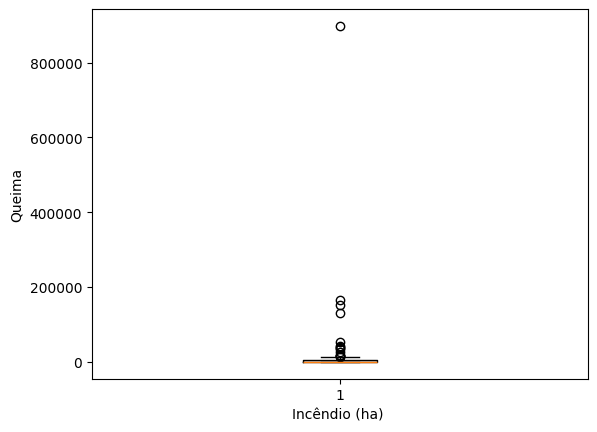

---------------------------------------------
Variável: Incêndio (ha) 
  Média:    18324.50
  Mediana:  632.80
  Q1:       54.69
  Q3:       5071.10
  Desvio:   93275.41
  CV:       509.02%
---------------------------------------------


In [ ]:
# A variável TOTAL INCÊNDIO (ha) está presente somente no dataset
# de 2025, os demais anos não possuem uma coluna equivalente.
# Porém, todos os datasets possuem a coluna Incêndio (ha), que será usada

df2025 = pd.read_excel("queimadas_conservacao.xlsx", sheet_name="2025")
df2023 = pd.read_excel("queimadas_conservacao.xlsx", sheet_name="2023")
df2022 = pd.read_excel("queimadas_conservacao.xlsx", sheet_name="2022")

colunas = [
    df2025["Incêndio (ha)"],
    df2023["Incêndio (ha)"],
    df2022["Incêndio (ha) "]
]

for col in colunas:
    pos_dispersao(col, "boxplot")

- A partir da análise dos gráficos e das medidas comparativas é possível dizer que o ano de 2025 foi o que teve a menor incidência de incêndios.

- 2022 foi o ano com a maior mediana (632.8), seguido por 2023 (293.63) e por fim 2025 (171.46), além disso, 2025 também foi o ano com outliers com valores mais baixos, indo até pouco mais de 400000.

- Os anos mais críticos em áreas queimadas foram 2022 e 2023, como visto pelos valores elevados do desvio padrão.

### Tarefa 2: Desmatamentos em unidades de conservação ambiental no Brasil

- O segundo conjunto de dados traz dados sobre desmatamento em unidades de conservação
ambiental (UC).
Para essa conjunto de dados, observe-o, e elabore seis perguntas que você possa responder usando
os dados desse conjunto.
Responda cada uma delas, analisando os resultados obtidos, e, se possível, use gráficos, medidas
e tabelas para ilustrar sua discussão.

In [ ]:
df_desmatamento = pd.read_excel("tabela_de_desmatamento_ucs_2025.xlsx")
amazonia = pd.read_excel("tabela_de_desmatamento_ucs_2025.xlsx", sheet_name="Amazônia", header=1).reset_index(drop=True)
pantanal = pd.read_excel("tabela_de_desmatamento_ucs_2025.xlsx", sheet_name="Pantanal", header=1).reset_index(drop=True)
mata = pd.read_excel("tabela_de_desmatamento_ucs_2025.xlsx", sheet_name="Mata Atlântica", header=1).reset_index(drop=True)
pampa = pd.read_excel("tabela_de_desmatamento_ucs_2025.xlsx", sheet_name="Pampa", header=1).reset_index(drop=True)
cerrado = pd.read_excel("tabela_de_desmatamento_ucs_2025.xlsx", sheet_name="Cerrado", header=1).reset_index(drop=True)
caatinga = pd.read_excel("tabela_de_desmatamento_ucs_2025.xlsx", sheet_name="Caatinga", header=1).reset_index(drop=True)

dataframes = [amazonia, pantanal, mata, pampa, cerrado, caatinga]

### 1. Qual UC apresenta o maior e menor desmatamento total acumulado até 2025 em cada região?

In [ ]:
regioes = ["Amazônia", "Pantanal", "Mata Atlântica", "Pampa", "Cerrado", "Caatinga"]

def min_max(df):
    df = df[df["unidade de conservação"].notna()]

    uc_max = df.loc[df["TOTAL"].idxmax()]
    uc_min = df.loc[df["TOTAL"].idxmin()]

    print("UC com MAIOR desmatamento:")
    print(f"{uc_max[["unidade de conservação", "TOTAL"]]}\n")

    print("UC com MENOR desmatamento:")
    print(f"{uc_min[["unidade de conservação", "TOTAL"]]}\n")

for x, data in enumerate(dataframes):
  print(f"========= {regioes[x]} =========")
  min_max(data)

========= Amazônia =========
UC com MAIOR desmatamento:
unidade de conservação    FLONA do Jamanxim
TOTAL                             227634.31
Name: 39, dtype: object

UC com MENOR desmatamento:
unidade de conservação    PARNA Serra da Mocidade
TOTAL                                        9.07
Name: 70, dtype: object

========= Pantanal =========
UC com MAIOR desmatamento:
unidade de conservação    ESEC de Taiamã
TOTAL                               6.78
Name: 0, dtype: object

UC com MENOR desmatamento:
unidade de conservação    PARNA do Pantanal Matogrossense
TOTAL                                                0.86
Name: 1, dtype: object

========= Mata Atlântica =========
UC com MAIOR desmatamento:
unidade de conservação    APA da Bacia do Rio Paraíba do Sul
TOTAL                                               146252.7
Name: 2, dtype: object

UC com MENOR desmatamento:
unidade de conservação    FLONA de Nísia Floresta
TOTAL                                         0.2
Name: 36, dtype

### 2. Qual foi a tendência temporal do desmatamento entre 2007 e 2025 na região amazônica? Há anos de pico ou queda significativa?

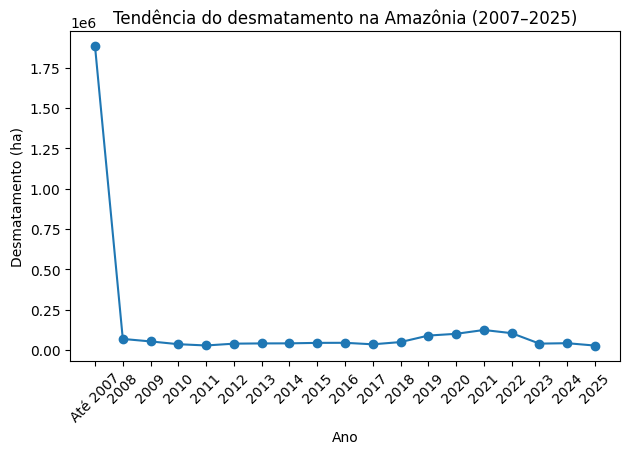

In [ ]:
col_anos = [
    "Até 2007", 2008, 2009, 2010, 2011, 2012,
    2013, 2014, 2015, 2016, 2017, 2018, 2019,
    2020, 2021, 2022, 2023, 2024, 2025
]

anos = []
totais = []

for col in col_anos:
    anos.append(str(col))
    totais.append(amazonia[col].sum())

total_desmatamento = pd.DataFrame({
    "Ano": anos,
    "Total": totais
})

plt.plot(total_desmatamento["Ano"], total_desmatamento["Total"], marker="o")
plt.xticks(rotation=45)
plt.title("Tendência do desmatamento na Amazônia (2007–2025)")
plt.xlabel("Ano")
plt.ylabel("Desmatamento (ha)")
plt.tight_layout()
plt.show()

- De acordo com o gráfico, após 2008 e té 2018 o desmatamento na região Amazônica se mantinha em uma média com poucas oscilações, mas a partir de 2019 houve uma alta no desmatamento, que só veio a diminuir a partir de 2023 e se manteve estável com a média anterior nos anos seguintes.

### 3. Qual é a relação entre a área total da UC e o desmatamento acumulado na região amazônica? UCs maiores desmatam mais proporcionalmente?

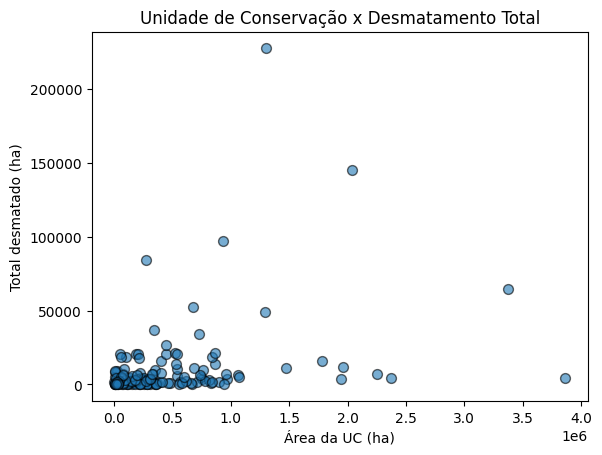

In [ ]:
plt.scatter(
    amazonia["área_ha_uc"],
    amazonia["TOTAL"],
    alpha=0.6,
    edgecolors="black",
    s=50
)
plt.title("Unidade de Conservação x Desmatamento Total")
plt.xlabel("Área da UC (ha)")
plt.ylabel("Total desmatado (ha)")
plt.show()

- Não existe uma relação entre quanto maior a área da UC maior o desmatamento, na verdade, os desmatamentos tendem a se concentrar em UCs com uma área total menor e, em poucos e isolados casos, UCs com 1,5 e 2,0 tiveraam a maior área desmatada.

### 4. Quantas unidades de conservação possuem desmatamento inferior a 1000 ha em cada bioma?

In [ ]:
for x, data in enumerate(dataframes):
  dataframe_zeros = data[data["TOTAL"] <= 1000].index
  print(f"================ {regioes[x]} ================")
  print(f"Quantidade de UCs com desmatamento < 1000 ha: {len(dataframe_zeros)}\n")

================ Amazônia ================
Quantidade de UCs com desmatamento < 1000 ha: 39

================ Pantanal ================
Quantidade de UCs com desmatamento < 1000 ha: 3

================ Mata Atlântica ================
Quantidade de UCs com desmatamento < 1000 ha: 73

================ Pampa ================
Quantidade de UCs com desmatamento < 1000 ha: 1

================ Cerrado ================
Quantidade de UCs com desmatamento < 1000 ha: 19

================ Caatinga ================
Quantidade de UCs com desmatamento < 1000 ha: 21



### 5. Em quais UCs da região amazônica houve aumento expressivo do desmatamento nos últimos cinco anos (2021–2025)?

In [ ]:
df_filtrado = amazonia[amazonia["unidade de conservação"].str.upper() != "TOTAL"].copy()

anos_recentes = [2021, 2022, 2023, 2024, 2025]

df_filtrado["Aumento_21_25"] = df_filtrado[2025] - df_filtrado[2021]

uc_aumento_expressivo = df_filtrado[df_filtrado["Aumento_21_25"] > 0].sort_values(
    by="Aumento_21_25", ascending=False
)

print("Top 10 UCs com maior aumento absoluto de desmatamento (2021-2025):")
print(uc_aumento_expressivo[["unidade de conservação", 2021, 2025, "Aumento_21_25"]].head(10))

Top 10 UCs com maior aumento absoluto de desmatamento (2021-2025):
        unidade de conservação    2021    2025  Aumento_21_25
74             REBIO do Gurupi  495.03  1438.0         942.97
59            PARNA do Juruena   70.40   856.0         785.60
37             FLONA do Iquiri   82.08   603.0         520.92
77           REBIO do Manicoré   21.32   119.0          97.68
73            REBIO do Guaporé   16.91   108.0          91.09
53       PARNA de Pacaás Novos    0.00    57.0          57.00
84         RESEX Arióca Pruanã  124.67   152.0          27.33
134  REVIS do Sauim-de-Coleira    0.00    27.0          27.00
48         FLONA Mapiá-Inauini    8.97    28.0          19.03
43             FLONA do Parima    0.00    19.0          19.00


### 6. Quais regiões (ou tipos de UC: APA, ARIE, PARNA...) concentram maior desmatamento total?

--- Concentração de Desmatamento por Tipo de UC ---
  Tipo_UC      TOTAL
3   FLONA  467894.44
7   RESEX  454161.57
0     APA  154871.14
4   PARNA  148160.54
6   REBIO  138013.30
2    ESEC   73195.78
1    ARIE    1863.11
8   REVIS      90.00
5     RDS      29.11

Total Desmatado na Amazônia: 2876557.98 ha
Total Desmatado no Pantanal: 15.280000000000001 ha
Total Desmatado na Mata Atlântica: 789761.74 ha
Total Desmatado na Pampa: 57462.15 ha
Total Desmatado no Cerrado: 1563516.054 ha
Total Desmatado na Caatinga: 1895072.6680000003 ha


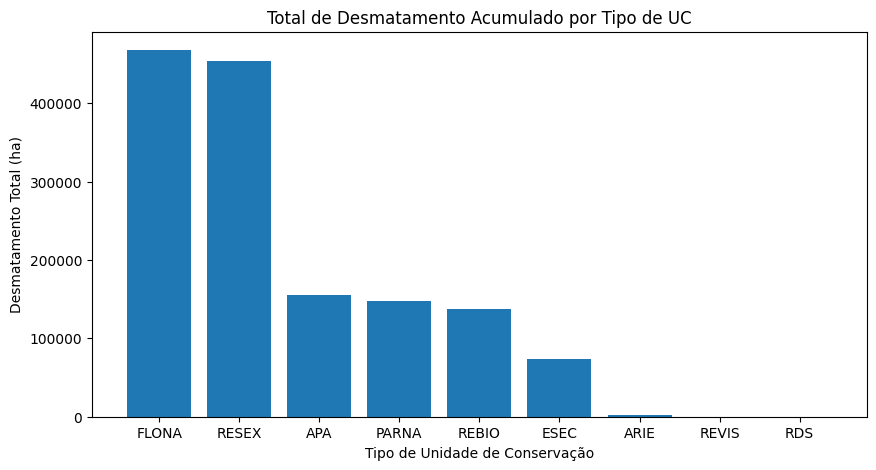

In [60]:
df_analise = amazonia[amazonia["unidade de conservação"].str.upper() != "TOTAL"].copy()

df_analise["Tipo_UC"] = df_analise["unidade de conservação"].str.split().str[0].str.upper()

desmatamento_por_tipo = df_analise.groupby("Tipo_UC")["TOTAL"].sum().reset_index()

desmatamento_por_tipo = desmatamento_por_tipo.sort_values(by="TOTAL", ascending=False)

print("--- Concentração de Desmatamento por Tipo de UC ---")
print(desmatamento_por_tipo)

print("\nTotal Desmatado na Amazônia:", amazonia[amazonia["unidade de conservação"].str.upper() != "TOTAL"]["TOTAL"].sum(), "ha")
print("Total Desmatado no Pantanal:", pantanal[pantanal["unidade de conservação"].str.upper() != "TOTAL"]["TOTAL"].sum(), "ha")
print("Total Desmatado na Mata Atlântica:", mata[mata["unidade de conservação"].str.upper() != "TOTAL"]["TOTAL"].sum(), "ha")
print("Total Desmatado na Pampa:", pampa[pampa["unidade de conservação"].str.upper() != "TOTAL"]["TOTAL"].sum(), "ha")
print("Total Desmatado no Cerrado:", cerrado[cerrado["unidade de conservação"].str.upper() != "TOTAL"]["TOTAL"].sum(), "ha")
print("Total Desmatado na Caatinga:", caatinga[caatinga["unidade de conservação"].str.upper() != "TOTAL"]["TOTAL"].sum(), "ha")

plt.figure(figsize=(10, 5))
plt.bar(desmatamento_por_tipo["Tipo_UC"], desmatamento_por_tipo["TOTAL"])

plt.title("Total de Desmatamento Acumulado por Tipo de UC")
plt.xlabel("Tipo de Unidade de Conservação")
plt.ylabel("Desmatamento Total (ha)")
plt.ticklabel_format(style='plain', axis='y')

plt.show()